Original shape: (971, 736, 3)


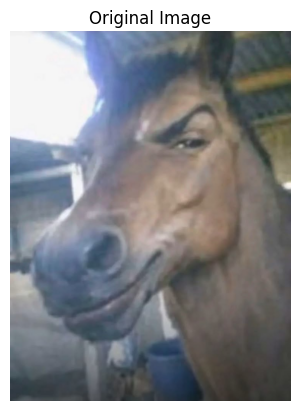

Low-res shape: (32, 32, 3)


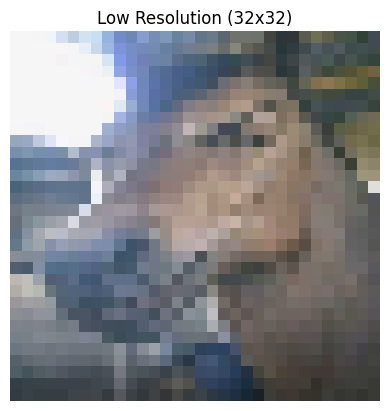

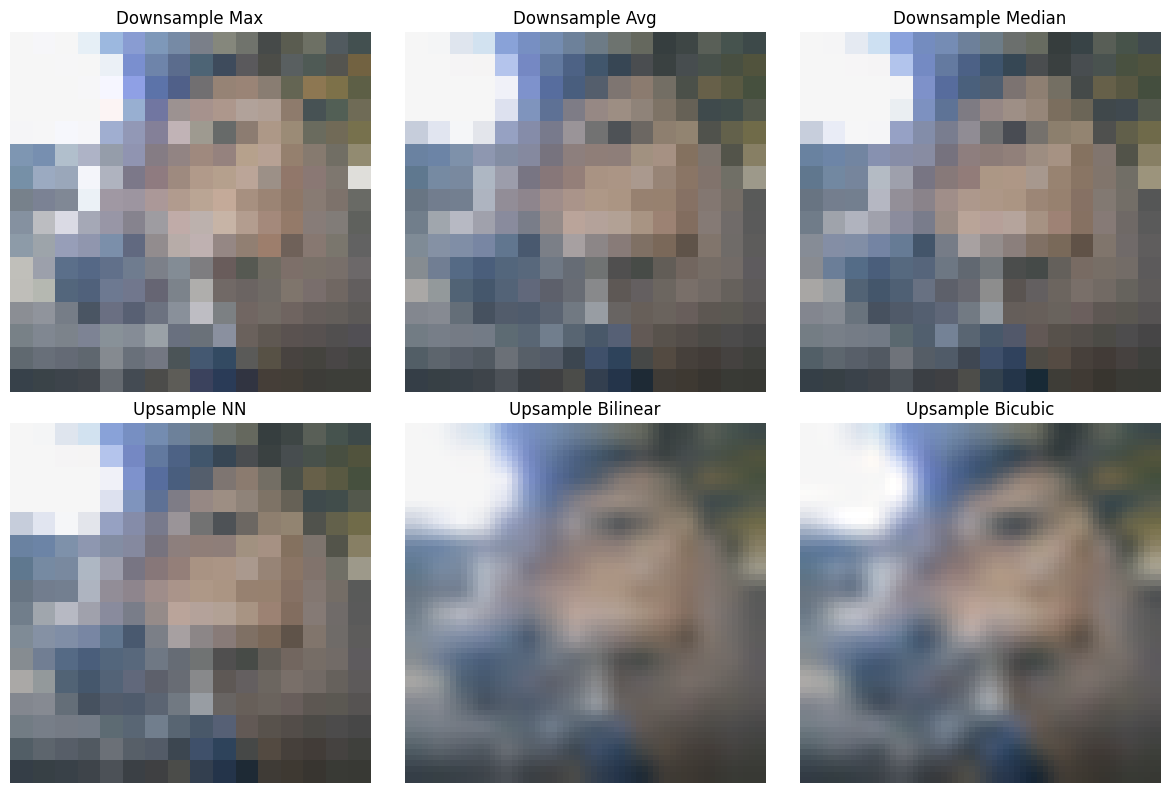

=== ANALYSIS ===

Down Sampling:
- Max: keeps strongest intensity → sharper but harsh.
- Average: smooths values → blurry.
- Median: removes noise → preserves edges better.

Up Sampling:
- Nearest Neighbor: blocky (pixelated).
- Bilinear: smoother but slightly blurry.
- Bicubic: smoothest and best visual quality.


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# =========================
# LOAD IMAGE
# =========================
img_path = "sample_data/download.jpg" # Changed to use an existing image

img = cv2.imread(img_path)

if img is None:
    print(f"Error: Image not found at {img_path}")
    # It's better to raise an exception or return in a function,
    # but for a script, exit() is fine, though it stops the kernel.
    # For demonstration, we'll let it proceed to show the cvtColor error if exit() is commented.
    exit()

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

print("Original shape:", img.shape)

plt.imshow(img)
plt.title("Original Image")
plt.axis("off")
plt.show()


# =========================
# FORCE LOW RESOLUTION
# =========================
low_res = cv2.resize(img, (32, 32))

print("Low-res shape:", low_res.shape)

plt.imshow(low_res)
plt.title("Low Resolution (32x32)")
plt.axis("off")
plt.show()


# =========================
# DOWN SAMPLING
# =========================
def downsample(image, factor=2, method="avg"):
    h, w, c = image.shape
    new_h, new_w = h // factor, w // factor
    result = np.zeros((new_h, new_w, c), dtype=np.uint8)

    for i in range(new_h):
        for j in range(new_w):
            block = image[i*factor:(i+1)*factor, j*factor:(j+1)*factor]

            if method == "max":
                result[i, j] = np.max(block.reshape(-1, c), axis=0)

            elif method == "avg":
                result[i, j] = np.mean(block.reshape(-1, c), axis=0)

            elif method == "median":
                result[i, j] = np.median(block.reshape(-1, c), axis=0)

    return result.astype(np.uint8)


ds_max = downsample(low_res, 2, "max")
ds_avg = downsample(low_res, 2, "avg")
ds_med = downsample(low_res, 2, "median")


# =========================
# UPSAMPLING (FROM DOWNSAMPLED)
# =========================
def upsample(image, scale=4):
    nn = cv2.resize(image, None, fx=scale, fy=scale, interpolation=cv2.INTER_NEAREST)
    bilinear = cv2.resize(image, None, fx=scale, fy=scale, interpolation=cv2.INTER_LINEAR)
    bicubic = cv2.resize(image, None, fx=scale, fy=scale, interpolation=cv2.INTER_CUBIC)
    return nn, bilinear, bicubic


us_nn, us_bilinear, us_bicubic = upsample(ds_avg, 4)


# =========================
# DISPLAY RESULTS
# =========================
titles = [
    "Downsample Max", "Downsample Avg", "Downsample Median",
    "Upsample NN", "Upsample Bilinear", "Upsample Bicubic"
]

images = [ds_max, ds_avg, ds_med, us_nn, us_bilinear, us_bicubic]

plt.figure(figsize=(12, 8))

for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()


# =========================
# ANALYSIS OUTPUT
# =========================
print("=== ANALYSIS ===")

print("\nDown Sampling:")
print("- Max: keeps strongest intensity → sharper but harsh.")
print("- Average: smooths values → blurry.")

print("- Median: removes noise → preserves edges better.")

print("\nUp Sampling:")
print("- Nearest Neighbor: blocky (pixelated).")
print("- Bilinear: smoother but slightly blurry.")
print("- Bicubic: smoothest and best visual quality.")
